Step 0: Connect to Drive and Inspect the Structure

In [ ]:
from google.colab import drive
import os

# 1. Mount your Google Drive into the Colab session
drive.mount('/content/drive')

# 2. Update this path to match exactly where your folder sits in your Drive
# For example, if it's right in your main Drive folder, use: '/content/drive/MyDrive/cell_images'
# If it's inside another folder, update it accordingly.
drive_folder_path = '/content/drive/MyDrive/Malaria_Dataset'

print("Contents of your Drive folder:")
try:
    print(os.listdir(drive_folder_path))
except FileNotFoundError:
    print(f"Could not find the folder at {drive_folder_path}. Please check the folder name in your Drive!")

Mounted at /content/drive
Contents of your Drive folder:
['archive.zip']


Step 1: Import all necessary libraries

In [ ]:
import os
import json
import shutil
import matplotlib.pyplot as plt

# Core Machine Learning Framework
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Google Colab Integration Tools
from google.colab import drive
from google.colab import files

print("All libraries imported successfully!")
print(f"TensorFlow Version: {tf.__version__}")

All libraries imported successfully!
TensorFlow Version: 2.20.0


Step 2: Unzip and Map the Duplication

In [ ]:
# 1. Unzip the archive from your Drive into Colab's high-speed local disk
!unzip -q "/content/drive/MyDrive/Malaria_Dataset/archive.zip" -d "/content/malaria_local"

import os

# 2. Define the exact path where the actual image directories live
# Because of the duplication, the true path is nested inside the double cell_images folder:
data_dir = "/content/malaria_local/cell_images/cell_images/"

# 3. Verify that we see ONLY the two correct folders now
if os.path.exists(data_dir):
    print("Success! Verified clean folders:", os.listdir(data_dir))
else:
    print("Path wasn't quite right. Let's look at what was created:", os.listdir("/content/malaria_local/cell_images/"))

replace /content/malaria_local/cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: Success! Verified clean folders: ['Uninfected', 'Parasitized']


Step 3: Preprocessing generators

In [ ]:
# 1. Point to our verified local directory
data_dir = "/content/malaria_local/cell_images/cell_images/"
BATCH_SIZE = 32
IMG_SIZE = (150, 150)

# 2. Configure real-time image augmentations to make the model robust
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2 # 80/20 Split
)

# 3. Stream the training images
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

# 4. Stream the validation images
val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


Step 4: Preview Cells

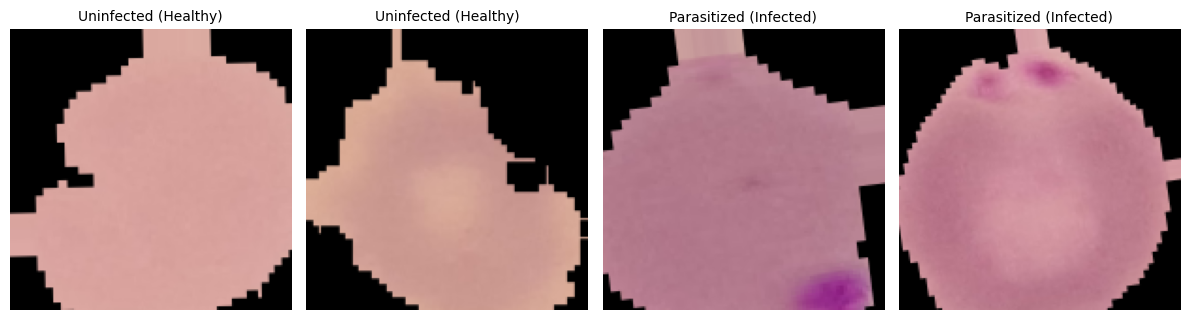

In [ ]:
import matplotlib.pyplot as plt

# 1. Pull exactly one batch (32 images) from your training stream
images, labels = next(train_generator)

# 2. Set up a grid to look at the first 4 cell images
plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i + 1)

    # Show the cell image
    plt.imshow(images[i])

    # Label 0 = Parasitized (Infected), Label 1 = Uninfected (Healthy)
    status = "Parasitized (Infected)" if labels[i] == 0 else "Uninfected (Healthy)"
    plt.title(status, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

Step 5: Compile and Fit (Train) the Model

In [ ]:
from tensorflow.keras import layers, models

# Build the CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile tracking Sensitivity (Recall) for medical accuracy
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

# Run the fitting engine for 5 test epochs
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

# Save the model artifact locally
model.save('/content/malaria_cell.h5')
print("\nModel trained successfully and saved as malaria_cell.h5!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 186s 262ms/step - accuracy: 0.7467 - loss: 0.5234 - recall: 0.8344 - val_accuracy: 0.9163 - val_loss: 0.3378 - val_recall: 0.9706
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 180s 261ms/step - accuracy: 0.9267 - loss: 0.2503 - recall: 0.9654 - val_accuracy: 0.9167 - val_loss: 0.1868 - val_recall: 0.9593
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 179s 261ms/step - accuracy: 0.9478 - loss: 0.1852 - recall: 0.9673 - val_accuracy: 0.9352 - val_loss: 0.1808 - val_recall: 0.9590
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 176s 255ms/step - accuracy: 0.9505 - loss: 0.1694 - recall: 0.9687 - val_accuracy: 0.9403 - val_loss: 0.1760 - val_recall: 0.9728
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 176s 255ms/step - accuracy: 0.9528 - loss: 0.1614 - recall: 0.9686 - val_accuracy: 0.9456 - val_loss: 0.1791 - val_recall: 0.9597



Model trained successfully and saved as malaria_cell.h5!


Step 6: Download the Weights File

In [ ]:
from google.colab import files
files.download('/content/malaria_cell.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>